In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [17]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
data.shape

(1338, 7)

In [6]:
data=pd.read_csv("..//insurance.csv")


In [16]:
data["children"].unique()


array([0, 1, 3, 2, 5, 4])

In [18]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
data["gender"].map()

In [35]:
le=LabelEncoder()
data["sex"]=le.fit_transform(data["sex"])
data["region"]=le.fit_transform(data["region"])
data["smoker"]=le.fit_transform(data["smoker"])

In [36]:
X=data.drop("charges",axis=1)
y=data["charges"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [37]:
model=LinearRegression()
model.fit(X_train,y_train)
prediction=model.predict(X_test)

In [53]:
print("R2_score:",r2_score(y_test,prediction))

R2_score: 0.783346310736454


In [49]:
print("mean_squared_error:",mean_squared_error(prediction,y_test))

mean_squared_error: 33635210.43117839


In [48]:
print("mean_absolute_error:",mean_absolute_error(prediction,y_test))

mean_absolute_error: 4186.508898366432


In [54]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

comparison.head(10)

,Actual,Predicted
764,9095.06825,8924.407244
887,5272.17580,7116.295018
890,29330.98315,36909.013521
1293,9301.89355,9507.874691
259,33750.29180,27013.350008
1312,4536.25900,10790.779562
899,2117.33885,226.298446
752,14210.53595,16942.715999
1286,3732.62510,1056.630794
707,10264.44210,11267.919973


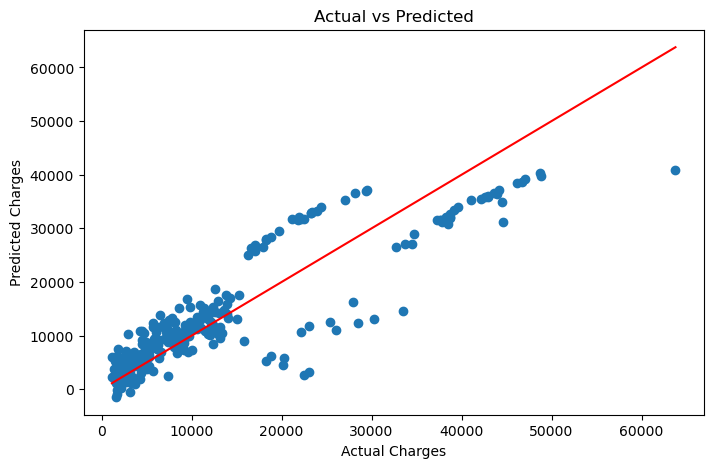

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()